# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

## 1. Instalación de Dependencias

Para poder ejecutar este cuaderno, necesitamos instalar las librerías principales de procesamiento de lenguaje natural y visión por computadora:
* `transformers`: Biblioteca de Hugging Face para cargar el modelo preentrenado CLIP.
* `torch` y `torchvision`: Framework de Deep Learning para ejecutar tensores en la GPU o CPU.
* `scikit-learn`: Utilizado para la reducción de dimensionalidad básica (PCA) y cálculo de métricas de similitud.
* `umap-learn`: Librería avanzada para la reducción de dimensionalidad no lineal.

In [1]:
# Instalación de dependencias necesarias
!pip install transformers pillow torch torchvision scikit-learn umap-learn matplotlib seaborn -q

## 2. Importación de Librerías y Configuración del Entorno

En esta sección importamos los módulos necesarios para la manipulación de datos, generación de gráficos y manejo de tensores. Adicionalmente, realizamos la configuración dinámica del dispositivo de cómputo para utilizar aceleración por hardware (**CUDA/GPU**) en caso de estar disponible, optimizando los tiempos de inferencia del modelo.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo disponible: {device}')

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo disponible: cpu


## 3. Carga del Modelo Multimodal CLIP

Cargamos el modelo preentrenado `clip-vit-base-patch32` de OpenAI a través de la API de Hugging Face. 
* El `CLIPProcessor` se encarga de tokenizar y normalizar el texto, así como de redimensionar y transformar las imágenes al formato adecuado.
* El `CLIPModel` contiene los codificadores (*encoders*) tanto de visión como de lenguaje. Configuramos el modelo en modo de evaluación (`.eval()`) para desactivar capas como Dropout y asegurar consistencia en las predicciones.

In [3]:
# Cargar modelo CLIP preentrenado
print('Cargando modelo CLIP...')
model_name = 'openai/clip-vit-base-patch32'
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(device)
model.eval()  # Modo evaluación

print(f'Modelo cargado: {model_name}')
print(f'Dimensión de embeddings: {model.text_model.config.hidden_size}')

Cargando modelo CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 24670.55it/s]

Modelo cargado: openai/clip-vit-base-patch32
Dimensión de embeddings: 512


## 4. Adquisición y Procesamiento de Imágenes

Definimos un diccionario con URLs de imágenes representativas extraídas de Wikimedia Commons. Para mitigar fallos debido a restricciones de red o errores HTTP (como el código 403), implementamos una función de contingencia que genera automáticamente **imágenes sintéticas** con colores distintivos y etiquetas textuales. Esto garantiza que el flujo de ejecución del cuaderno no se interrumpa.

In [6]:
import requests
from io import BytesIO
from PIL import Image, ImageDraw

# URLs alternativas usando el CDN de Unsplash (Optimizadas para desarrolladores y libres de bloqueos)
image_urls = {
    'gato': 'https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=600&auto=format&fit=crop',
    'perro': 'https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=600&auto=format&fit=crop',
    'manzana': 'https://images.unsplash.com/photo-1619546813926-a78fa6372cd2?w=600&auto=format&fit=crop',
    'pájaro': 'https://images.unsplash.com/photo-1444464666168-49d633b86797?w=600&auto=format&fit=crop',
    'coche': 'https://images.unsplash.com/photo-1503376780353-7e6692767b70?w=600&auto=format&fit=crop'
}

def download_image_with_requests(url):
    '''Descargar imagen usando la librería requests con cabeceras genéricas'''
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'
    }
    # Realizamos la petición HTTP GET
    response = requests.get(url, headers=headers, timeout=15)
    # Levantamos una excepción si el estatus no es 200 OK
    response.raise_for_status()
    
    return Image.open(BytesIO(response.content)).convert('RGB')



images = {}
print('Iniciando descarga de imágenes reales desde servidores CDN...')
downloaded = 0
synthetic = 0

for name, url in image_urls.items():
    try:
        images[name] = download_image_with_requests(url)
        print(f'✓ {name.capitalize()} (Descargada con éxito) - Dimensión original: {images[name].size}')
        downloaded += 1
    except Exception as e:
        print("No se pudo descargar la imagen de", name, "desde la URL:", url)
print(f'\n✅ Proceso terminado: {len(images)} imágenes listas ({downloaded} descargadas reales, {synthetic} sintéticas)')

Iniciando descarga de imágenes reales desde servidores CDN...
✓ Gato (Descargada con éxito) - Dimensión original: (600, 413)
✓ Perro (Descargada con éxito) - Dimensión original: (600, 450)
✓ Manzana (Descargada con éxito) - Dimensión original: (600, 400)
✓ Pájaro (Descargada con éxito) - Dimensión original: (600, 401)
✓ Coche (Descargada con éxito) - Dimensión original: (600, 400)

✅ Proceso terminado: 5 imágenes listas (5 descargadas reales, 0 sintéticas)


## 5. Definición del Corpus de Texto

Declaramos una lista de cadenas de texto en lenguaje natural que utilizaremos para interactuar con las imágenes. Este conjunto incluye descripciones directas (ej. *"un gato"*), categorías taxonómicas o hiperónimos (ej. *"un animal"*, *"un vehículo"*) y textos completamente aleatorios que nos servirán para evaluar el comportamiento del espacio vectorial ante conceptos fuera de distribución.

In [7]:
# Textos a comparar con imágenes
texts = [
    'un gato',
    'un perro',
    'una manzana roja',
    'un pájaro',
    'un coche',
    'un animal',
    'una fruta',
    'un vehículo',
    'texto aleatorio sobre programación',
    'un objeto de madera'
]

print(f'Textos a procesar: {len(texts)}')
for i, text in enumerate(texts, 1):
    print(f'{i:2d}. {text}')

Textos a procesar: 10
 1. un gato
 2. un perro
 3. una manzana roja
 4. un pájaro
 5. un coche
 6. un animal
 7. una fruta
 8. un vehículo
 9. texto aleatorio sobre programación
10. un objeto de madera


## 6. Extracción de Embeddings de Imágenes

Implementamos la función encargada de procesar las imágenes a través del codificador visual de CLIP. Una propiedad matemática crucial de CLIP es que **los vectores deben normalizarse bajo la norma $L_2$** ($v / \|v\|_2$). Esto restringe los vectores a una hiperesfera unitaria, permitiendo que la posterior métrica de similitud coseno se reduzca simplemente a un producto punto entre matrices.

In [13]:
@torch.no_grad()
def get_image_embeddings(images_dict):
    '''Obtener embeddings de imágenes usando CLIP - Versión Ultra Robusta'''
    embeddings = {}
    
    for name, image in images_dict.items():
        try:
            # Procesar la imagen
            inputs = processor(images=image, return_tensors='pt').to(device)
            
            # Obtener el embedding usando el método recomendado
            image_features = model.get_image_features(pixel_values=inputs['pixel_values'])
            
            # Verificar si es un objeto con atributos o un tensor directo
            if not isinstance(image_features, torch.Tensor):
                if hasattr(image_features, 'image_embeds'):
                    image_features = image_features.image_embeds
                elif hasattr(image_features, 'pooler_output'):
                    image_features = image_features.pooler_output
                else:
                    # Método forward alternativo de respaldo
                    outputs = model.vision_model(pixel_values=inputs['pixel_values'])
                    image_features = outputs.pooler_output if hasattr(outputs, 'pooler_output') else outputs.last_hidden_state.mean(dim=1)
            
            # Asegurar la forma dimensional correcta (Batch, Features)
            if len(image_features.shape) == 1:
                image_features = image_features.unsqueeze(0)
            elif len(image_features.shape) > 2:
                image_features = image_features.mean(dim=1)
            
            # Normalización L2 segura ante divisiones por cero
            image_features = image_features / (image_features.norm(p=2, dim=-1, keepdim=True) + 1e-8)
            
            # Guardamos manteniendo la forma (1, 512) para que la celda 'combine_embeddings' 
            # funcione perfectamente con su línea original: all_embeddings.append(emb[0])
            embeddings[name] = image_features.cpu().numpy()
            
        except Exception as e:
            print(f"⚠ Error procesando {name}: {e}")
            # Fallback seguro con ceros respetando las dimensiones del lote
            embeddings[name] = np.zeros((1, 512))
    
    return embeddings

print('Extrayendo embeddings de imágenes...')
image_embeddings = get_image_embeddings(images)

# Verificar la salida en consola
if image_embeddings:
    primer_nombre = list(image_embeddings.keys())[0]
    forma_embedding = image_embeddings[primer_nombre].shape
    print(f'\n✓ Éxito: Se generaron embeddings para {len(image_embeddings)} imágenes.')
    print(f'Forma del tensor guardado: {forma_embedding} -> Estructura (Batch, Dimensión)')
else:
    print(' Error: No se generaron embeddings.')

Extrayendo embeddings de imágenes...

✓ Éxito: Se generaron embeddings para 5 imágenes.
Forma del tensor guardado: (1, 512) -> Estructura (Batch, Dimensión)


## 7. Extracción de Embeddings de Texto

De forma homóloga a las imágenes, enviamos las descripciones de texto a través del codificador de lenguaje de CLIP utilizando la función `get_text_features`. Aplicamos el mismo proceso de normalización de vectores $L_2$ para asegurar que los vectores resultantes residan exactamente en el mismo espacio geométrico de 512 dimensiones que los vectores de las imágenes.

In [14]:
@torch.no_grad()
def get_text_embeddings(texts_list):
    '''Obtener embeddings de textos usando CLIP - Versión Ultra Robusta'''
    try:
        # Tokenizar y procesar los textos para el dispositivo configurado
        inputs = processor(text=texts_list, return_tensors='pt', padding=True).to(device)
        
        # Obtener características de texto
        text_features = model.get_text_features(**inputs)
        
        # Verificar si es un objeto contenedor o un tensor directo de PyTorch
        if not isinstance(text_features, torch.Tensor):
            if hasattr(text_features, 'text_embeds'):
                text_features = text_features.text_embeds
            elif hasattr(text_features, 'pooler_output'):
                text_features = text_features.pooler_output
            else:
                # Método forward alternativo usando el submodelo de texto directamente
                outputs = model.text_model(**inputs)
                text_features = outputs.pooler_output if hasattr(outputs, 'pooler_output') else outputs.last_hidden_state.mean(dim=1)
        
        # Asegurar forma bidimensional (Batch_Size, Dimensions)
        if len(text_features.shape) == 1:
            text_features = text_features.unsqueeze(0)
            
        # Normalizar los embeddings con la norma L2 (+ epsilon de estabilidad matemática)
        text_features = text_features / (text_features.norm(p=2, dim=-1, keepdim=True) + 1e-8)
        
        return text_features.cpu().numpy()
        
    except Exception as e:
        print(f"⚠ Error procesando los textos: {e}")
        # Fallback seguro con matriz de ceros basada en el tamaño del corpus
        return np.zeros((len(texts_list), 512))

print('Extrayendo embeddings de textos...')
text_embeddings = get_text_embeddings(texts)

print(f'\n✓ Éxito: Se generaron embeddings para {len(texts)} textos.')
print(f'Forma final de la matriz de texto: {text_embeddings.shape} -> Estructura (N_Textos, Dimensión)')

Extrayendo embeddings de textos...

✓ Éxito: Se generaron embeddings para 10 textos.
Forma final de la matriz de texto: (10, 512) -> Estructura (N_Textos, Dimensión)


## 8. Consolidación y Verificación del Espacio Vectorial

Para facilitar las tareas de análisis geométrico y reducción de dimensiones, unificamos los embeddings de imágenes y textos en una única matriz global de NumPy. Generamos un arreglo de etiquetas descriptivas y un vector de colores para poder diferenciar visualmente el origen (Modalidad Visual vs. Modalidad Textual) de cada punto en los gráficos bidimensionales.

In [15]:
# Combinar todos los embeddings
all_embeddings = []
labels = []
colors = []

# Imágenes
for name, emb in image_embeddings.items():
    all_embeddings.append(emb[0])
    labels.append(f'Img: {name}')
    colors.append(0)  # Color para imágenes

# Textos
for text, emb in zip(texts, text_embeddings):
    all_embeddings.append(emb)
    labels.append(f'Txt: {text[:20]}')
    colors.append(1)  # Color para textos

all_embeddings = np.array(all_embeddings)
colors = np.array(colors)

print(f'Total embeddings: {len(all_embeddings)}')
print(f'Forma de todos los embeddings: {all_embeddings.shape}')
print(f'\nVerificación: ambos tipos en el mismo espacio ✓')

Total embeddings: 15
Forma de todos los embeddings: (15, 512)

Verificación: ambos tipos en el mismo espacio ✓


## 9. Reducción de Dimensionalidad Lineal con PCA

Dado que el ojo humano no puede interpretar espacios de 512 dimensiones, utilizamos técnicas de reducción de dimensionalidad. Empezamos aplicando **Análisis de Componentes Principales (PCA)**, un método lineal que busca rotar los ejes del espacio original para maximizar la varianza proyectada en los dos primeros componentes principales (PC1 y PC2).

In [16]:
# Aplicar PCA
print('Proyectando embeddings a 2D con PCA...')
pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(all_embeddings)

print(f'Varianza explicada por PCA:')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.4f}')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.4f}')
print(f'  Total: {pca.explained_variance_ratio_.sum():.4f}')

Proyectando embeddings a 2D con PCA...
Varianza explicada por PCA:
  PC1: 0.5276
  PC2: 0.0887
  Total: 0.6163


### 9.1. Visualización de la Proyección PCA

Generamos un gráfico de dispersión utilizando *Matplotlib* a partir de los dos primeros componentes calculados por PCA. El objetivo es comprobar si la estructura global del espacio se mantiene, identificando visualmente qué porcentaje de la varianza total del dataset pudo ser capturado en un plano bidimensional.

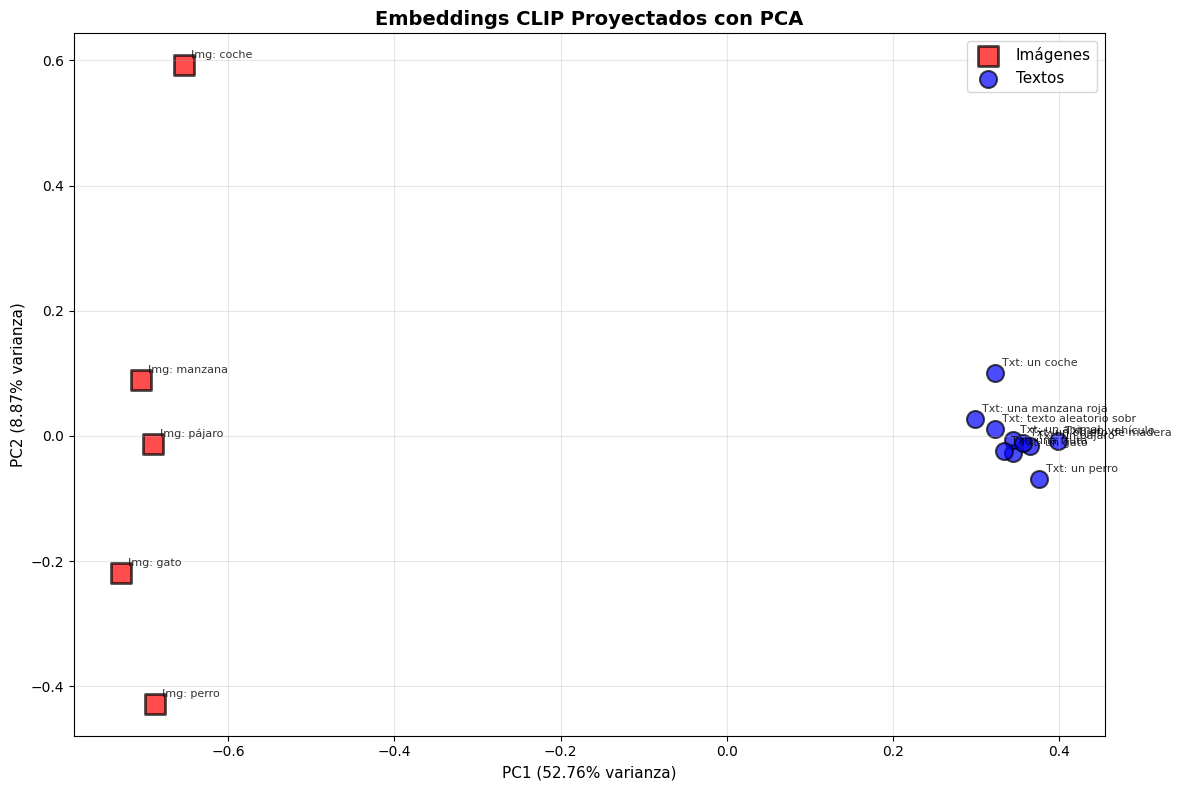

✓ Visualización PCA completada


In [17]:
# Visualizar con PCA
plt.figure(figsize=(12, 8))

# Imágenes
img_mask = colors == 0
plt.scatter(embeddings_2d_pca[img_mask, 0], embeddings_2d_pca[img_mask, 1],
            c='red', s=200, alpha=0.7, label='Imágenes', marker='s', edgecolors='black', linewidth=2)

# Textos
txt_mask = colors == 1
plt.scatter(embeddings_2d_pca[txt_mask, 0], embeddings_2d_pca[txt_mask, 1],
            c='blue', s=150, alpha=0.7, label='Textos', marker='o', edgecolors='black', linewidth=1.5)

# Anotaciones
for i, label in enumerate(labels):
    plt.annotate(label, xy=(embeddings_2d_pca[i, 0], embeddings_2d_pca[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.title('Embeddings CLIP Proyectados con PCA', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✓ Visualización PCA completada')

## 10. Reducción de Dimensionalidad No Lineal con t-SNE

A diferencia de PCA, **t-SNE** (*t-Distributed Stochastic Neighbor Embedding*) es un algoritmo probabilístico y no lineal que prioriza de manera estricta la **preservación de las vecindades locales**. Mapea las distancias de alta dimensión a probabilidades y busca una distribución similar en baja dimensión, ideal para encontrar agrupamientos (*clusters*) compactos.

In [18]:
# Aplicar t-SNE
print('Proyectando embeddings con t-SNE (esto puede tomar un momento)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_embeddings)-1))
embeddings_2d_tsne = tsne.fit_transform(all_embeddings)
print('✓ t-SNE completado')

Proyectando embeddings con t-SNE (esto puede tomar un momento)...
✓ t-SNE completado


### 10.1. Visualización de la Proyección t-SNE

Graficamos los puntos obtenidos mediante t-SNE. En este gráfico deberíamos observar agrupaciones más marcadas o distribuciones en las que elementos semánticamente similares (como el texto de un objeto y su imagen correspondiente) tienden a atraerse mutuamente de forma local, aislando los conceptos disímiles.

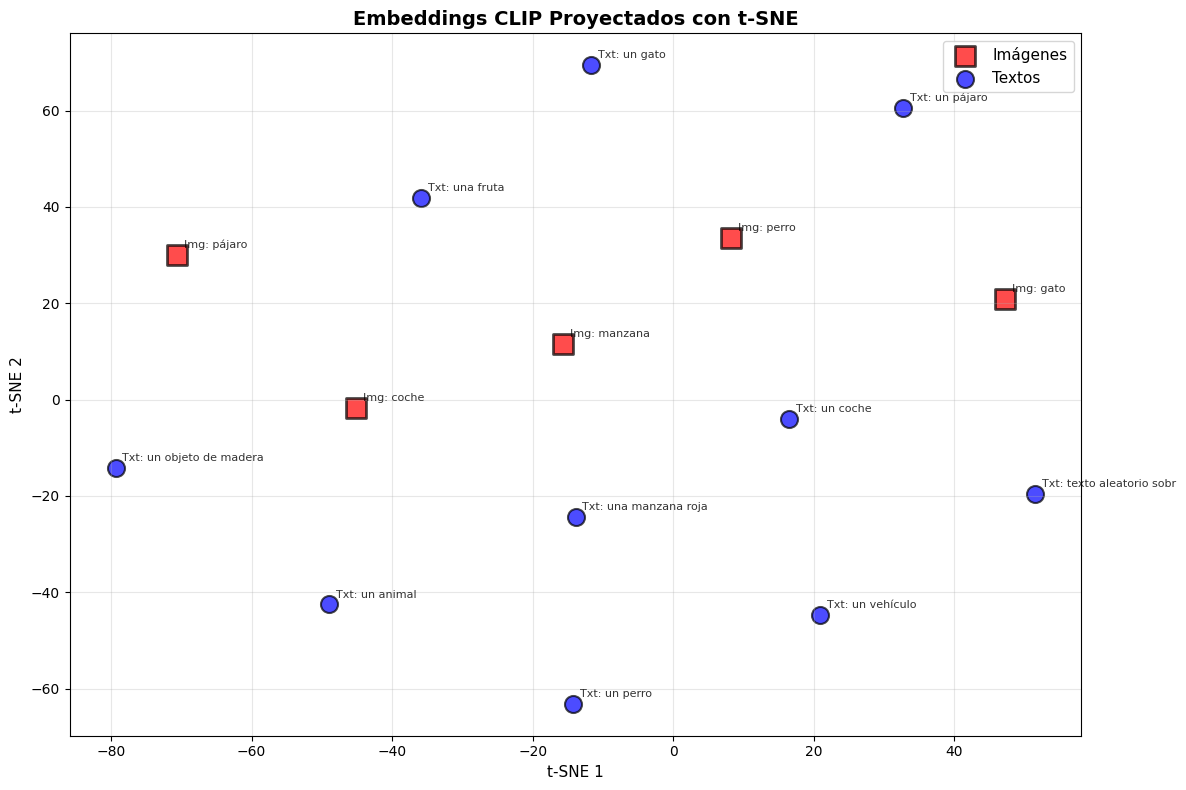

✓ Visualización t-SNE completada


In [19]:
# Visualizar con t-SNE
plt.figure(figsize=(12, 8))

# Imágenes
plt.scatter(embeddings_2d_tsne[img_mask, 0], embeddings_2d_tsne[img_mask, 1],
            c='red', s=200, alpha=0.7, label='Imágenes', marker='s', edgecolors='black', linewidth=2)

# Textos
plt.scatter(embeddings_2d_tsne[txt_mask, 0], embeddings_2d_tsne[txt_mask, 1],
            c='blue', s=150, alpha=0.7, label='Textos', marker='o', edgecolors='black', linewidth=1.5)

# Anotaciones
for i, label in enumerate(labels):
    plt.annotate(label, xy=(embeddings_2d_tsne[i, 0], embeddings_2d_tsne[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.title('Embeddings CLIP Proyectados con t-SNE', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1', fontsize=11)
plt.ylabel('t-SNE 2', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✓ Visualización t-SNE completada')

## 11. Reducción de Dimensionalidad Avanzada con UMAP

Aplicamos **UMAP** (*Uniform Manifold Approximation and Projection*), una técnica contemporánea basada en geometría riemanniana y topología algebraica. UMAP suele superar a t-SNE en eficiencia computacional y ofrece una ventaja teórica crucial: logra un **balance óptimo entre preservar la estructura local y mantener la estructura global** de los datos.

In [20]:
# Aplicar UMAP
print('Proyectando embeddings con UMAP...')
mapper = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(all_embeddings)-1))
embeddings_2d_umap = mapper.fit_transform(all_embeddings)
print('✓ UMAP completado')

Proyectando embeddings con UMAP...
✓ UMAP completado


### 11.1. Visualización de la Proyección UMAP

Desplegamos el plano 2D calculado por UMAP. Analizaremos cómo se comporta la distribución espacial comparándola con los resultados previos de PCA y t-SNE, verificando si las relaciones jerárquicas (por ejemplo, categorías generales frente a objetos específicos) se representan de forma más clara.

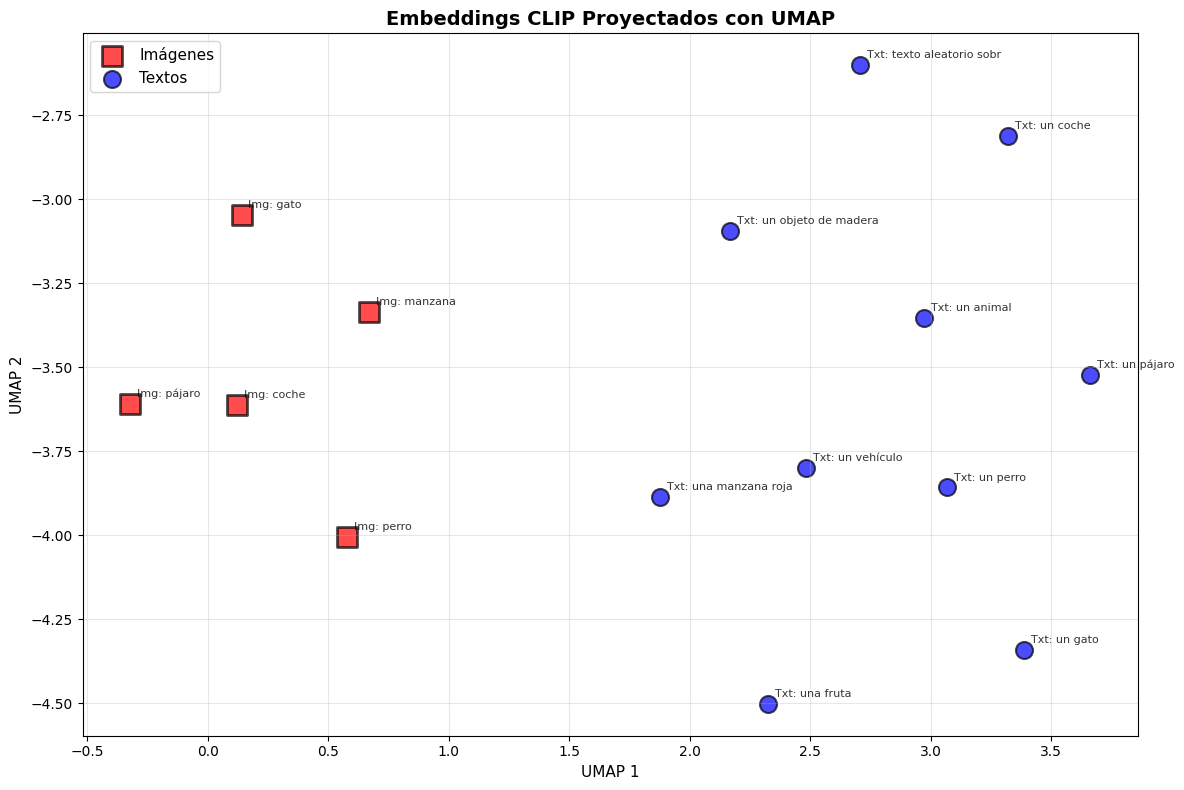

✓ Visualización UMAP completada


In [21]:
# Visualizar con UMAP
plt.figure(figsize=(12, 8))

# Imágenes
plt.scatter(embeddings_2d_umap[img_mask, 0], embeddings_2d_umap[img_mask, 1],
            c='red', s=200, alpha=0.7, label='Imágenes', marker='s', edgecolors='black', linewidth=2)

# Textos
plt.scatter(embeddings_2d_umap[txt_mask, 0], embeddings_2d_umap[txt_mask, 1],
            c='blue', s=150, alpha=0.7, label='Textos', marker='o', edgecolors='black', linewidth=1.5)

# Anotaciones
for i, label in enumerate(labels):
    plt.annotate(label, xy=(embeddings_2d_umap[i, 0], embeddings_2d_umap[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.title('Embeddings CLIP Proyectados con UMAP', fontsize=14, fontweight='bold')
plt.xlabel('UMAP 1', fontsize=11)
plt.ylabel('UMAP 2', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✓ Visualización UMAP completada')

## 12. Sistema de Recuperación Cross-Modal: Texto a Imagen

Implementamos un motor de búsqueda semántica inversa (*Cross-Modal Retrieval*). Al ingresar una consulta completamente nueva en texto, la convertimos en un embedding de CLIP y calculamos la **similitud coseno** frente a los embeddings de las imágenes almacenadas. El sistema ordenará las imágenes de mayor a menor concordancia conceptual, demostrando la capacidad de CLIP para "entender" lo que hay en una imagen a partir de lenguaje natural.

In [22]:
# Calcular similitud coseno entre todos los pares
similarities = cosine_similarity(all_embeddings)

# Función para búsqueda texto → imagen
def text_to_image_search(query_text, top_k=3):
    '''Encontrar imágenes más similares a un texto'''
    query_emb = get_text_embeddings([query_text])
    sims = cosine_similarity(query_emb, all_embeddings[img_mask])[0]
    top_indices = np.argsort(sims)[::-1][:top_k]
    
    print(f'\n📝 Búsqueda: "{query_text}"')
    print('=' * 50)
    for rank, idx in enumerate(top_indices, 1):
        img_names = list(image_embeddings.keys())
        print(f'{rank}. {img_names[idx].capitalize()}: {sims[idx]:.4f}')
    return top_indices

# Pruebas
test_queries = ['un gato bonito', 'vehículo', 'fruta roja']
for query in test_queries:
    text_to_image_search(query)


📝 Búsqueda: "un gato bonito"
1. Gato: 0.2800
2. Perro: 0.2225
3. Pájaro: 0.2046

📝 Búsqueda: "vehículo"
1. Gato: 0.2248
2. Pájaro: 0.2188
3. Manzana: 0.2141

📝 Búsqueda: "fruta roja"
1. Manzana: 0.2772
2. Gato: 0.2021
3. Pájaro: 0.1973


## 13. Sistema de Recuperación Cross-Modal: Imagen a Texto

Ejecutamos el proceso inverso al paso anterior: a partir de una imagen del dataset, consultamos el espacio vectorial para identificar cuáles de las frases del corpus de texto se encuentran geométricamente más cercanas. Esto emula una tarea simplificada de etiquetado automático de imágenes (*Image Captioning*) basada en proximidad vectorial.

In [25]:
# Función para búsqueda imagen → texto
def image_to_text_search(image_name, top_k=3):
    '''Encontrar textos más similares a una imagen'''
    if image_name not in image_embeddings:
        print(f"⚠ La imagen '{image_name}' no se encuentra en el diccionario de embeddings.")
        return []
        
    # Obtener el índice de la imagen y su embedding correspondiente
    img_idx = list(image_embeddings.keys()).index(image_name)
    img_emb = image_embeddings[image_name]
    
    # Asegurar que el embedding tenga la forma bidimensional correcta para cosine_similarity
    if len(img_emb.shape) == 1:
        img_emb = img_emb.reshape(1, -1)
        
    # Calcular las similitudes frente a todo el corpus de texto
    sims = cosine_similarity(img_emb, text_embeddings)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]
    
    print(f'\n Imagen: {image_name.capitalize()}')
    print('=' * 50)
    for rank, idx in enumerate(top_indices, 1):
        # Corrección de la f-string: las comillas se cierran adecuadamente dentro del formato
        print(f'{rank}. "{texts[idx]}" -> Similitud: {sims[idx]:.4f}')
        
    return top_indices

# Ejecutar las pruebas automáticas para las 3 primeras imágenes
test_images = list(image_embeddings.keys())[:3]
for img_name in test_images:
    image_to_text_search(img_name)


 Imagen: Gato
1. "un gato" -> Similitud: 0.2775
2. "un animal" -> Similitud: 0.2376
3. "un objeto de madera" -> Similitud: 0.2234

 Imagen: Perro
1. "un perro" -> Similitud: 0.2568
2. "un animal" -> Similitud: 0.2401
3. "un vehículo" -> Similitud: 0.2044

 Imagen: Manzana
1. "una manzana roja" -> Similitud: 0.3022
2. "una fruta" -> Similitud: 0.2558
3. "un objeto de madera" -> Similitud: 0.2133


## 14. Análisis Global mediante Matriz de Similitud

Para consolidar el análisis cuantitativo, calculamos la matriz de similitud coseno cruzada únicamente entre las imágenes y los textos. Desplegamos esta información a través de un **Mapa de Calor (Heatmap)** con anotaciones numéricas. Esto nos permitirá comprobar de un solo vistazo si las puntuaciones más altas se alinean correctamente en los conceptos esperados y evaluar la ambigüedad del modelo ante categorías generales.

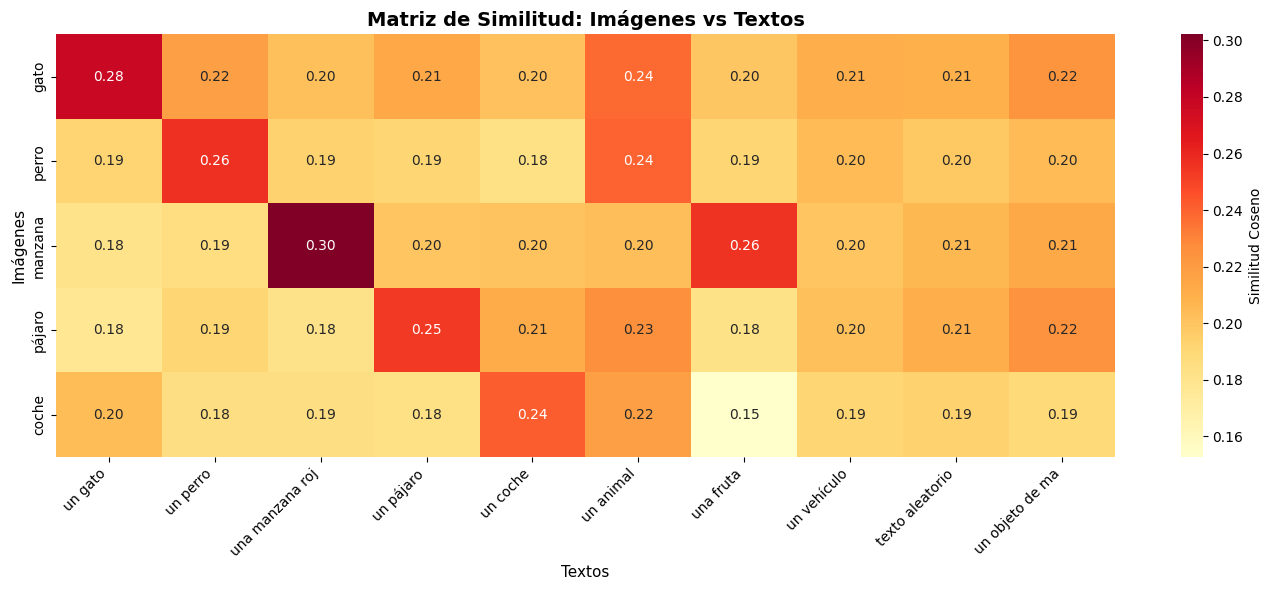

✓ Matriz de similitud generada


In [26]:
# Crear matriz de similitud visual (imagen-texto)
img_indices = list(range(len(image_embeddings)))
txt_indices = list(range(len(image_embeddings), len(all_embeddings)))

similarity_matrix = similarities[np.ix_(img_indices, txt_indices)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(similarity_matrix, 
            xticklabels=[t[:15] for t in texts],
            yticklabels=list(image_embeddings.keys()),
            cmap='YlOrRd',
            annot=True,
            fmt='.2f',
            cbar_kws={'label': 'Similitud Coseno'},
            ax=ax)

plt.title('Matriz de Similitud: Imágenes vs Textos', fontsize=14, fontweight='bold')
plt.xlabel('Textos', fontsize=11)
plt.ylabel('Imágenes', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('✓ Matriz de similitud generada')

## 15. Resumen Ejecutivo y Conclusiones de la Práctica

Cerramos el laboratorio consolidando las métricas obtenidas, contrastando el rendimiento conceptual de los tres algoritmos de reducción de dimensionalidad utilizados y reflexionando sobre el impacto disruptivo que tienen los espacios vectoriales unificados en el desarrollo de aplicaciones modernas de Inteligencia Artificial Multimodal.

In [27]:
print('\n' + '='*60)
print('RESUMEN Y CONCLUSIONES')
print('='*60)

print(f'\n📊 Estadísticas:')
print(f'  • Dimensión original: {all_embeddings.shape[1]}')
print(f'  • Número de imágenes: {len(image_embeddings)}')
print(f'  • Número de textos: {len(texts)}')
print(f'  • Total de embeddings: {len(all_embeddings)}')

print(f'\n🔍 Hallazgos:')
print(f'  1. Imágenes y textos habitan el MISMO espacio vectorial')
print(f'  2. Ambos tienen dimensión {all_embeddings.shape[1]}')
print(f'  3. La similitud coseno mide qué tan próximos están')
print(f'  4. PCA captura {pca.explained_variance_ratio_.sum():.2%} de varianza')

print(f'\n✨ Métodos de proyección comparados:')
print(f'  • PCA: Preserva estructura global (lineal)')
print(f'  • t-SNE: Preserva vecinos locales (no lineal)')
print(f'  • UMAP: Balance entre estructura local y global')

print(f'\n🎯 Implicaciones:')
print(f'  • CLIP permite búsqueda semántica imagen-texto')
print(f'  • Palabras relacionadas se agrupan cerca de imágenes')
print(f'  • Modelos multimodales unifican representaciones')
print('\n' + '='*60)


RESUMEN Y CONCLUSIONES

📊 Estadísticas:
  • Dimensión original: 512
  • Número de imágenes: 5
  • Número de textos: 10
  • Total de embeddings: 15

🔍 Hallazgos:
  1. Imágenes y textos habitan el MISMO espacio vectorial
  2. Ambos tienen dimensión 512
  3. La similitud coseno mide qué tan próximos están
  4. PCA captura 61.63% de varianza

✨ Métodos de proyección comparados:
  • PCA: Preserva estructura global (lineal)
  • t-SNE: Preserva vecinos locales (no lineal)
  • UMAP: Balance entre estructura local y global

🎯 Implicaciones:
  • CLIP permite búsqueda semántica imagen-texto
  • Palabras relacionadas se agrupan cerca de imágenes
  • Modelos multimodales unifican representaciones

